7

In [1]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=10000, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

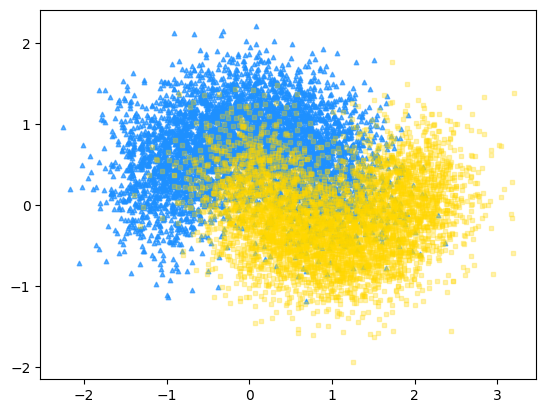

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], color="dodgerblue", s=10, alpha=0.7, marker="^")
plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], color="gold", s=10, alpha=0.3, marker="s")

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

dt_clf = DecisionTreeClassifier(random_state=42)
cross_val_score(dt_clf, X_train, y_train, cv=10).mean()

np.float64(0.7939999999999999)

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [None, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "max_leaf_nodes": [None, 2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
}

grid_search = GridSearchCV(dt_clf, param_grid, cv=10, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [None, 2, ...], 'max_leaf_nodes': [None, 2, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [5]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_).sort_values(by="mean_test_score", ascending=False).head(20)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
4,0.030268,0.001892,0.002436,0.000567,None,15,"{'max_depth': None, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
102,0.030787,0.002721,0.002032,0.000027,8,15,"{'max_depth': 8, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
130,0.028365,0.002216,0.002173,0.000493,10,15,"{'max_depth': 10, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
74,0.029938,0.003076,0.002143,0.000172,6,15,"{'max_depth': 6, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
88,0.030622,0.001367,0.002107,0.000160,7,15,"{'max_depth': 7, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
116,0.027699,0.001804,0.002057,0.000175,9,15,"{'max_depth': 9, 'max_leaf_nodes': 15}",0.860000,0.860000,0.853333,0.854667,0.861333,0.872000,0.860000,0.861333,0.856000,0.840000,0.857867,0.007687,1
103,0.035371,0.004362,0.002617,0.001196,8,20,"{'max_depth': 8, 'max_leaf_nodes': 20}",0.854667,0.858667,0.857333,0.853333,0.860000,0.872000,0.858667,0.861333,0.856000,0.840000,0.857200,0.007529,7
131,0.031281,0.003601,0.002051,0.000131,10,20,"{'max_depth': 10, 'max_leaf_nodes': 20}",0.854667,0.858667,0.857333,0.853333,0.860000,0.872000,0.858667,0.861333,0.856000,0.840000,0.857200,0.007529,7
117,0.027537,0.001663,0.001948,0.000096,9,20,"{'max_depth': 9, 'max_leaf_nodes': 20}",0.854667,0.858667,0.857333,0.853333,0.860000,0.872000,0.858667,0.861333,0.856000,0.840000,0.857200,0.007529,7
5,0.032725,0.001708,0.002254,0.000208,None,20,"{'max_depth': None, 'max_leaf_nodes': 20}",0.854667,0.858667,0.857333,0.853333,0.860000,0.872000,0.858667,0.861333,0.856000,0.840000,0.857200,0.007529,7


In [6]:
best_model = DecisionTreeClassifier(
    max_depth=6, 
    max_leaf_nodes=15, 
) 
cross_val_score(best_model, X_train, y_train, cv=10).mean()

np.float64(0.8578666666666667)

In [7]:
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)

0.8528

Similar score for cv and test means its not overfitting.